<a href="https://colab.research.google.com/github/AKookani/Qiskit_course/blob/Main/Qiskit1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Quantum Coding Course** (summer 2024)

**Instructors:**
Ali Kookani, Yousef Mafi

\

*Atlas Stem*

# Section 2: Qiskit running and simulation tools

*   Quantum_info
*   BasicSimulator
*   AerSimulator
*   Noise
*   Primitives

## Quantum Infromation (Quantum_info)

In [1]:
# Install the Qiskit library for quantum computing and ipywidgets for interactive widgets in Jupyter notebooks
!pip install qiskit ipywidgets

# Install the pylatexenc library for rendering LaTeX in Matplotlib figures
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=73bd66589c6dd3c23c0e22a1ffb5f506059aaa28f5440d313e49770e8ab47d4e
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
import qiskit
print(qiskit.__version__)

2.4.1


**Running Quantum Circuits**

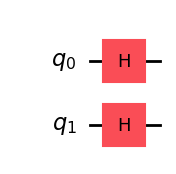

<IPython.core.display.Latex object>

In [3]:
# Import necessary Qiskit modules
import qiskit
from qiskit import QuantumCircuit  # Import QuantumCircuit class to create quantum circuits
from qiskit.quantum_info import Statevector  # Import Statevector class for quantum state representation

# Create a quantum circuit with 2 qubits
qc = QuantumCircuit(2)

# Apply the Hadamard gate to qubits 0 and 1 to create superposition states
qc.h([0, 1])

# Display the quantum circuit diagram using Matplotlib
display(qc.draw('mpl'))

# Create a statevector from the quantum circuit (representing the quantum state after the circuit operations)
state = Statevector.from_instruction(qc)

# Draw the quantum state in LaTeX format
state.draw('latex')

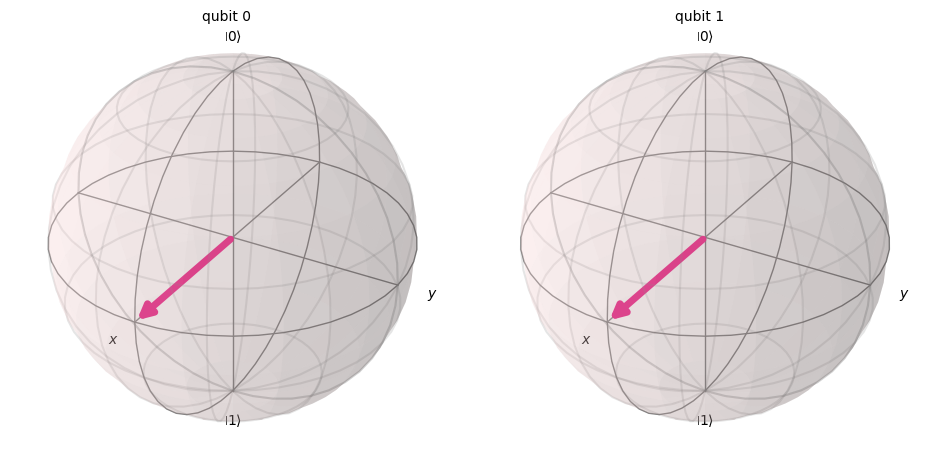

In [4]:
# Draw the quantum state in bloch sphere format for visualization
state.draw('bloch')

[0.25 0.25 0.25 0.25]
{np.str_('00'): np.int64(247), np.str_('01'): np.int64(261), np.str_('10'): np.int64(255), np.str_('11'): np.int64(261)}


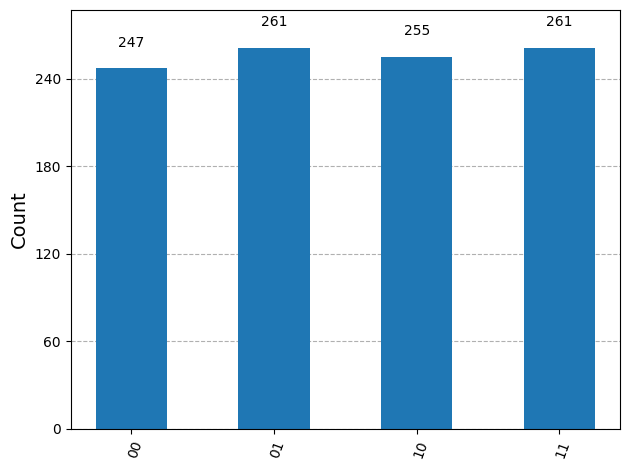

In [5]:
from qiskit.visualization import plot_histogram

# Get the probabilities of the quantum state
probs = state.probabilities()
print(probs)  # Print the calculated probabilities

# Simulate measuring the quantum state multiple times to get counts
counts = state.sample_counts(shots=1024)
print(counts)  # Print the sample counts

# Visualize the counts as a histogram
plot_histogram(counts)

In [6]:
# Sample measurements from the quantum state
samples = state.sample_memory(shots=10)

# Print the sampled measurement outcomes
print(samples)

['10' '11' '01' '01' '00' '11' '11' '01' '01' '00']


In [7]:
import qiskit.quantum_info as qi

# Define a sparse Pauli operator with specific terms and coefficients.
# The Pauli terms ['ZZ', 'XX', 'II'] correspond to tensor products of Pauli matrices
# (Z for the Z matrix, X for the X matrix, and I for the identity matrix).
# The coefficients [0.2, -0.3, 0.4] are the corresponding weights for these Pauli terms.
Operator = qi.SparsePauliOp(['ZZ', 'XX', 'IY'], [0.2, -0.3, 0.4])

# Convert the sparse Pauli operator into a full matrix operator.
# This produces the full matrix representation of the quantum operator based on the
# provided Pauli terms and their coefficients.
full_operator = Operator.to_operator()

# Visualize the full matrix operator in LaTeX format.
# This renders the operator in a LaTeX-formatted string for better readability in documentation or publications.
full_operator.draw('latex')

<IPython.core.display.Latex object>

0.2⋅(Z⊗Z)+(−0.3)⋅(X⊗X)+0.4⋅(I⊗Y)

In [8]:
# Calculate the expectation value of the Operator with respect to the quantum state
expectation_value = state.expectation_value(Operator)

# Print the calculated expectation value
print(expectation_value)

(-0.2999999999999999+0j)


For a pure state ∣𝜓⟩:<br />
⟨O⟩=⟨ψ∣O∣ψ⟩ <br />
<p>&nbsp;</p>
For a mixed state represented by a density matrix 𝜌: <br />
⟨O⟩=Tr(ρO)

In [9]:
# Create a density matrix from the quantum circuit 'qc' using qi.DensityMatrix
rho = qi.DensityMatrix(qc)

# Draw the density matrix in LaTeX format
rho.draw('latex')

<IPython.core.display.Latex object>

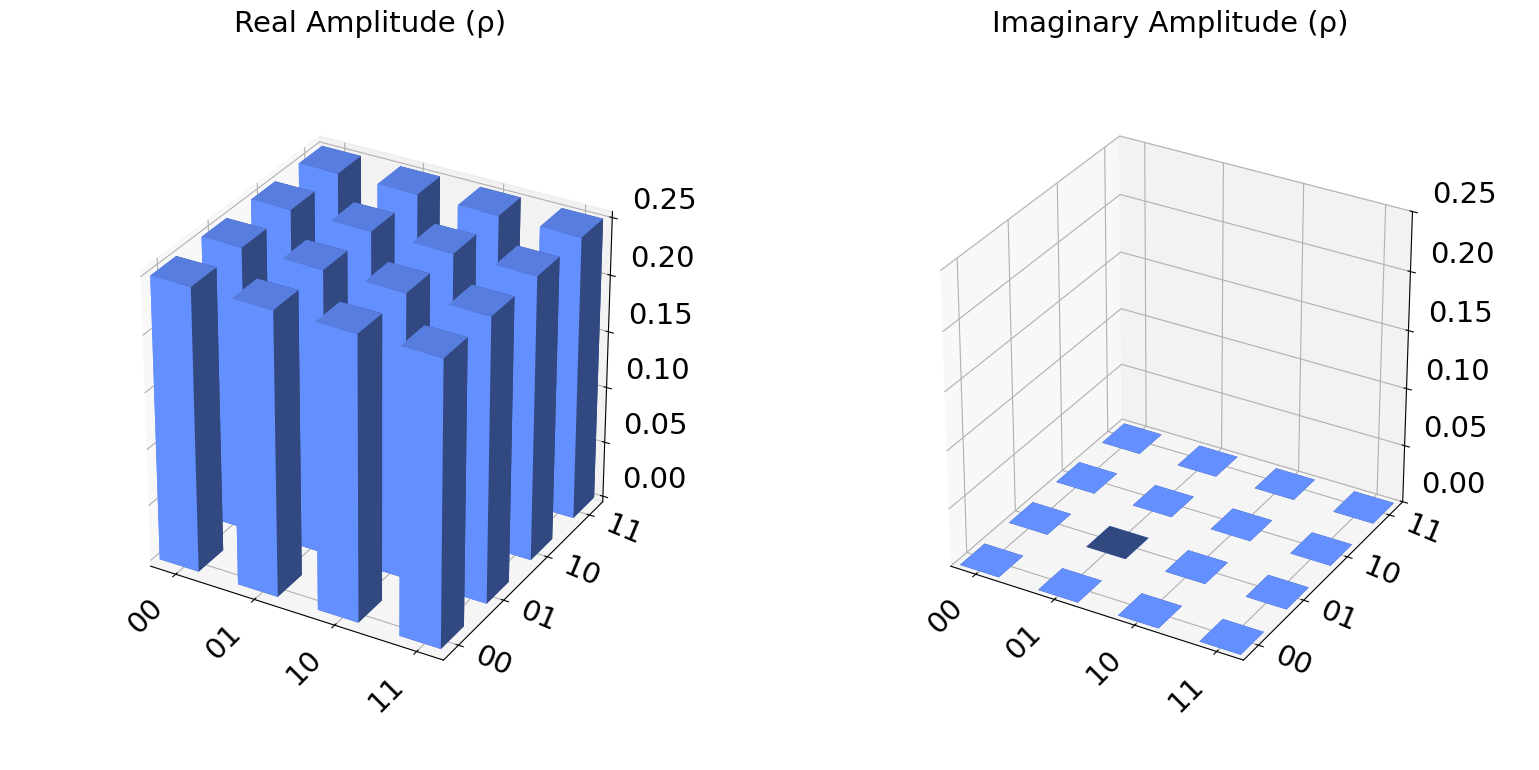

In [10]:
# Draw the density matrix 'rho' in cityscape format
rho.draw('city')

In [11]:
# Compute the partial trace of the density matrix 'rho' over the first qubit (qubit 0)
rho1 = qi.partial_trace(rho, [0])

# Draw the resulting density matrix 'rho1' in LaTeX format
rho1.draw('latex')

<IPython.core.display.Latex object>

$
ρ=Tr_A(ρ_{AB})
$

In [12]:
# Create a unitary operator from the quantum circuit 'qc' using qi.Operator
unitary = qi.Operator(qc)

# Draw the unitary operator in LaTeX format
unitary.draw('latex')

<IPython.core.display.Latex object>

**quantum_info limitation**

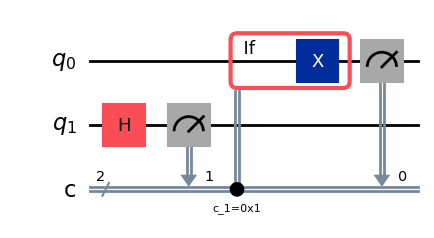

QiskitError: 'Circuits with control flow operations cannot be converted to an instruction.'

In [15]:
from qiskit.circuit import QuantumRegister, ClassicalRegister

# Create named registers (recommended for clarity with if_test)
qr = QuantumRegister(2, 'q')
cr = ClassicalRegister(2, 'c')
qc = QuantumCircuit(qr, cr)

# Apply a Hadamard gate to qubit 1
qc.h(qr[1])

# Mid-circuit measurement of qubit 1 → classical bit 1
qc.measure(qr[1], cr[1])

# Conditionally apply X to qubit 0 if classical bit 1 == 1
with qc.if_test((cr[1], 1)):
    qc.x(qr[0])

# Final measurement of qubit 0 → classical bit 0
qc.measure(qr[0], cr[0])

display(qc.draw('mpl'))

# Create a statevector from the quantum circuit 'qc'
qi.Statevector(qc)

## Simulation (AerSimulator)

**Simulate Circuit Using Qiskit Aer** (*AerSimulator*)

Finding state vectors in circuit with measurements

In [18]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.1 MB/s eta 0:00:00


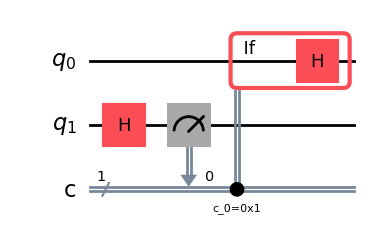

The result is almost half of the time 0 and half of the time 1 but **we don't know what the projected state is for each of these result**

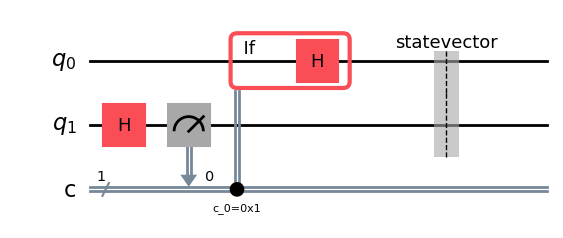

In [22]:
# Import the AerSimulator from the qiskit_aer module
from qiskit_aer import AerSimulator

# Initialize an Aer quantum simulator
simulator_aer = AerSimulator()

# Create named registers (recommended for clarity with if_test) with a quantum register size 2 and a classical register size 1
qr = QuantumRegister(2, 'q')
cr = ClassicalRegister(1, 'c')
qc = QuantumCircuit(qr, cr)

# Apply a Hadamard gate to the second qubit (qubit 1) of the quantum regsiter
qc.h(qr[1])

# Measure the second qubit (qubit 1) of the quantum regsiter on the classical register (classical bit 0)
qc.measure(qr[1], cr[0])

# Conditionally apply Hadamard to qubit 0 if classical bit 0 == 1
with qc.if_test((cr[0], 1)):
    qc.h(qr[0])

# Save the statevector of the quantum circuit
qc.save_statevector()

# Draw the quantum circuit using Matplotlib
qc.draw('mpl')

In [23]:
from qiskit import transpile

# Repeat the following process 5 times
for i in range(5):
    # Transpile the quantum circuit 'qc' for the Aer simulator backend
    qc_aer = transpile(qc, backend=simulator_aer)

    # Execute the transpiled quantum circuit on the Aer simulator
    result = simulator_aer.run(qc_aer).result()

    # Get the statevector from the result
    Psi = result.get_statevector()

    # Display the statevector in LaTeX format
    display(Psi.draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [ ]:
qc_basic = transpile(qc, backend=simulator_basic)

result = simulator_basic.run(qc_basic).result()
Psi = result.get_statevector()
display(Psi.draw('latex'))

TranspilerError: "Unable to translate the operations in the circuit: ['save_statevector', 'h', 'measure'] to the backend's (or manually specified) target basis: ['ry', 'measure', 'rz', 'delay', 'z', 'cy', 'tdg', 'rzz', 'x', 'ecr', 'cu', 'crz', 'rxx', 'sdg', 'cp', 'id', 'cz', 'cx', 'h', 'cswap', 'rccx', 'p', 'sxdg', 'unitary', 'sx', 'cry', 'crx', 'rx', 'cu3', 'u2', 'xx_plus_yy', 'snapshot', 'r', 's', 'dcx', 'store', 'ryy', 'rzx', 'csx', 'csdg', 't', 'ch', 'u1', 'cu1', 'u3', 'global_phase', 'y', 'swap', 'xx_minus_yy', 'iswap', 'reset', 'ccx', 'cs', 'barrier', 'ccz', 'u']. This likely means the target basis is not universal or there are additional equivalence rules needed in the EquivalenceLibrary being used. For more details on this error see: https://docs.quantum.ibm.com/api/qiskit/qiskit.transpiler.passes.BasisTranslator#translation-errors"

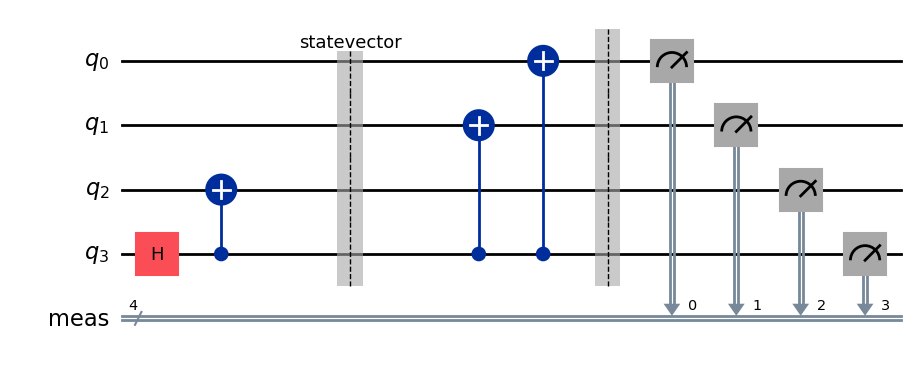

In [ ]:
qc = QuantumCircuit(4)
qc.h(3)
qc.cx(3, 2)
qc.save_statevector()
qc.cx(3, 1)
qc.cx(3, 0)
qc.measure_all()
qc.draw('mpl')

In [ ]:
# Transpile the quantum circuit 'qc' for the Aer simulator backend
qc_aer = transpile(qc, backend=simulator_aer)

# Execute the transpiled quantum circuit on the Aer simulator
result = simulator_aer.run(qc_aer).result()

# Get the statevector from the result
Psi = result.get_statevector()

# Display the statevector in LaTeX format
display(Psi.draw('latex'))

<IPython.core.display.Latex object>

**Efficient Simulators**

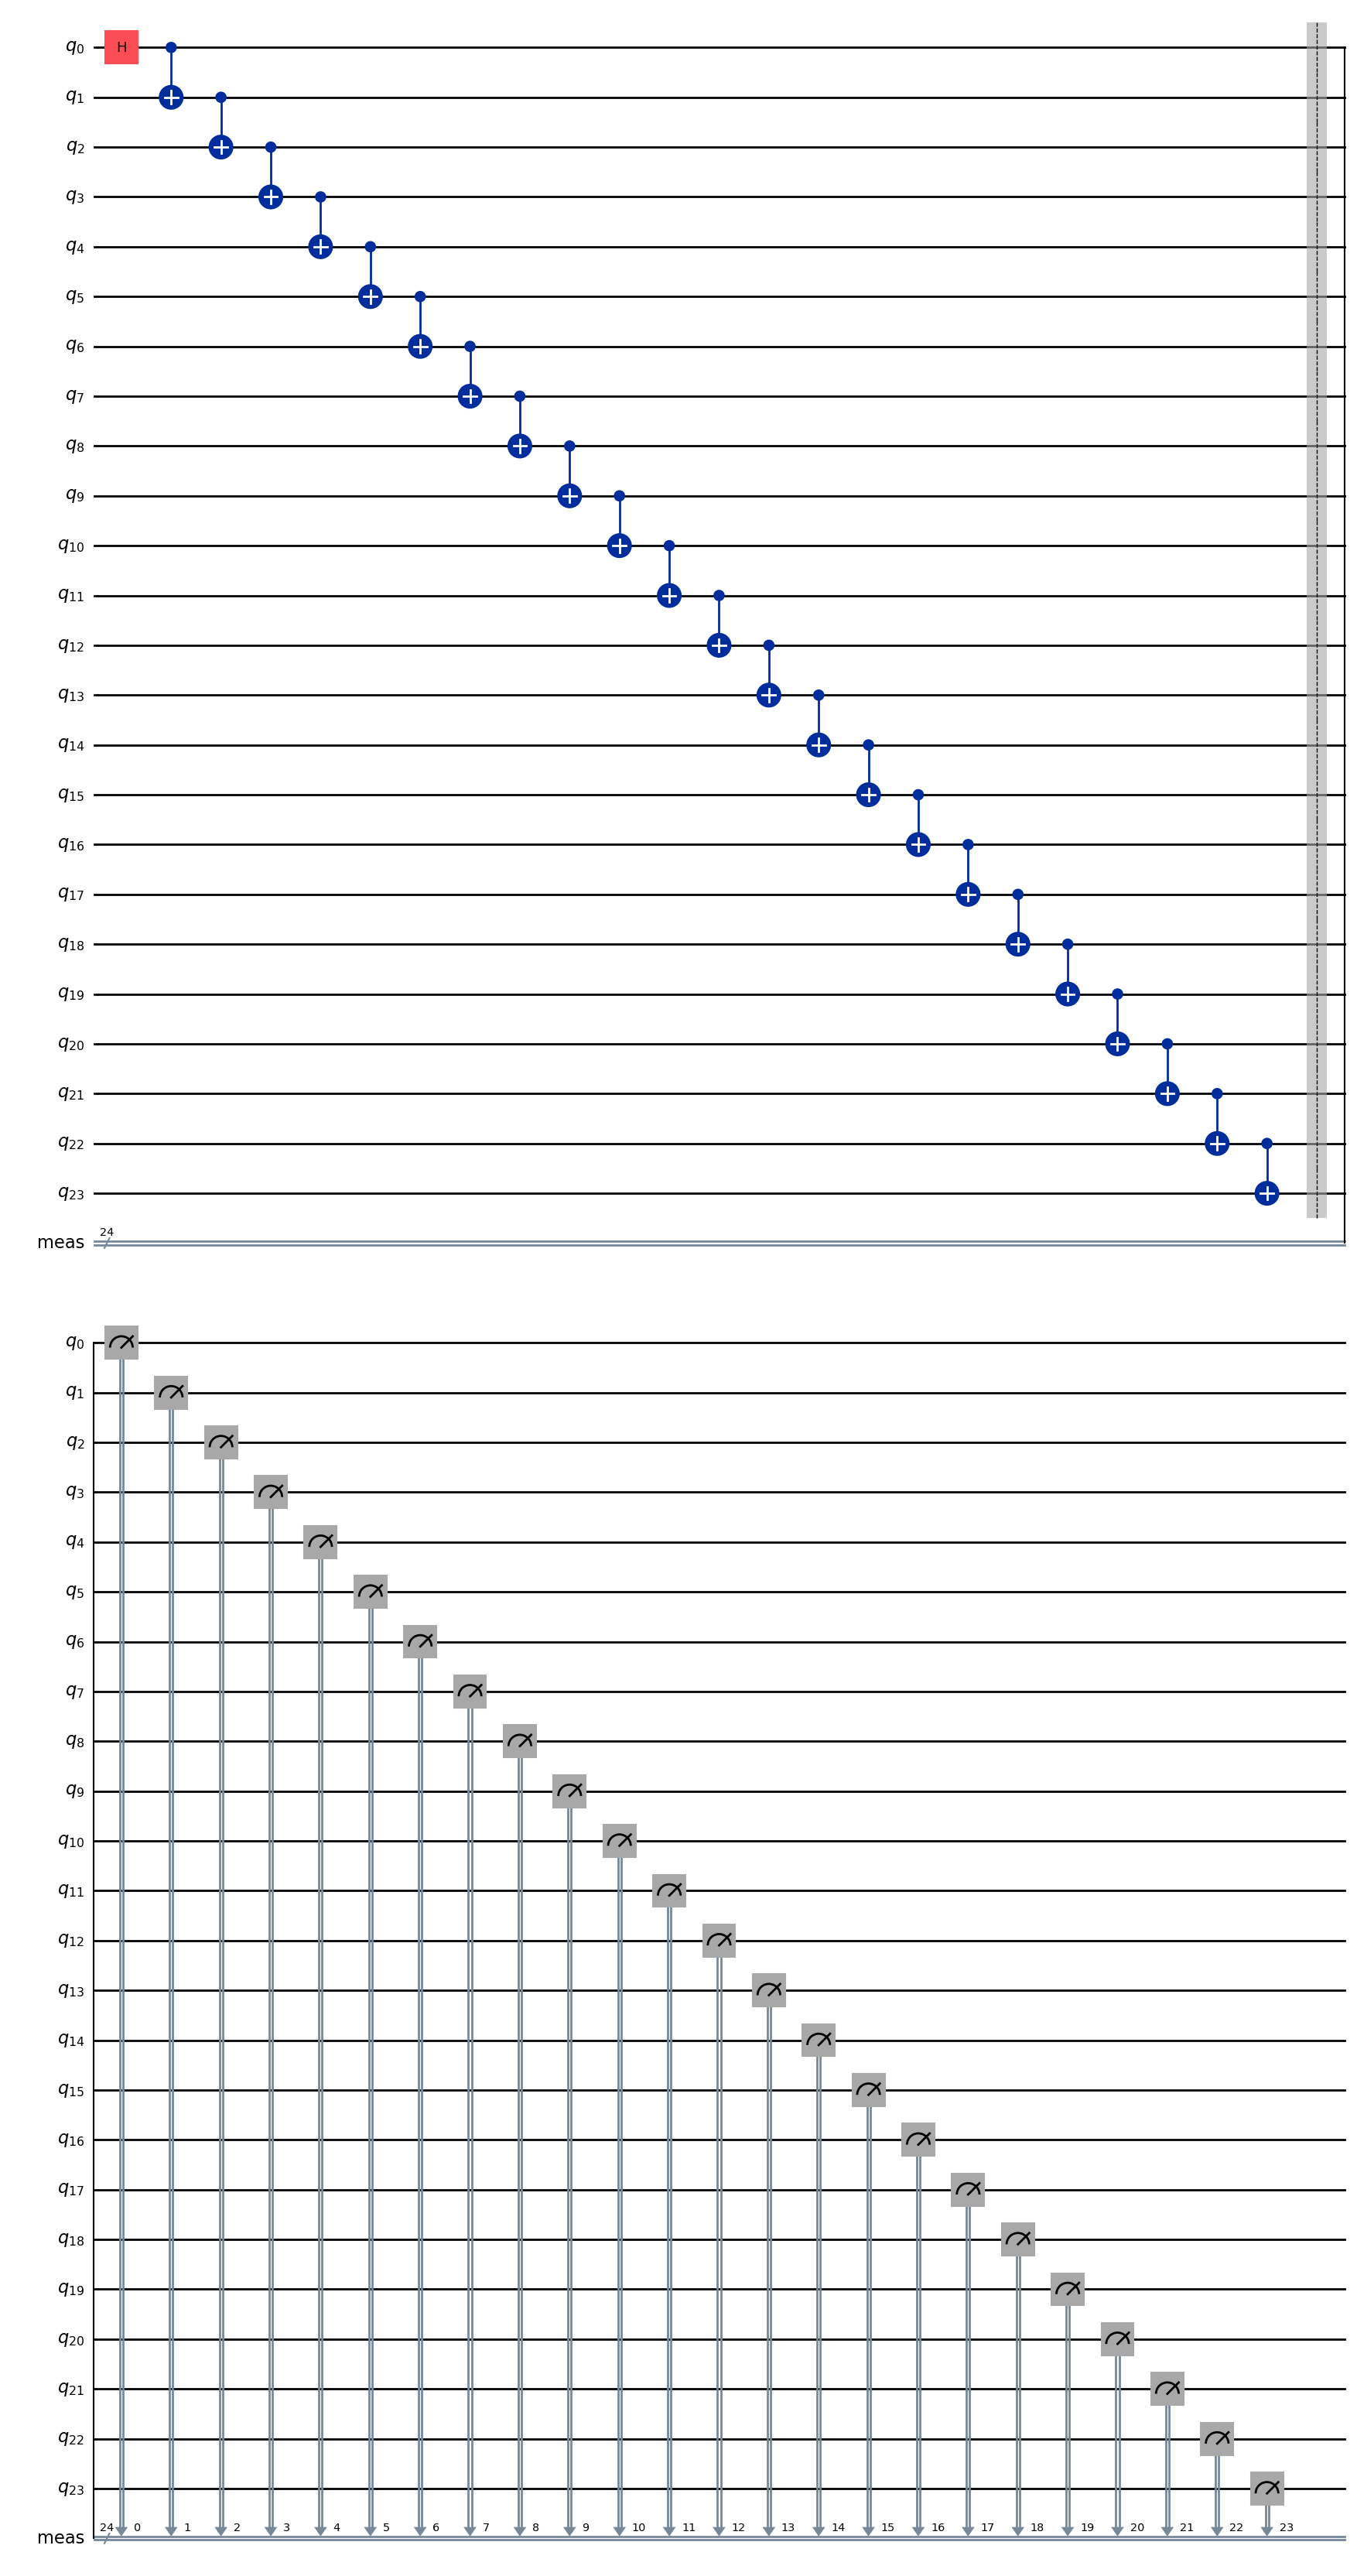

In [ ]:
# Set the number of qubits to 24
n = 24

# Create a quantum circuit with 'n' qubits
qc = QuantumCircuit(n)

# Apply a Hadamard gate to the last qubit (qubit n-1)
qc.h(0)

# Apply a series of CNOT (CX) gates in a chain, from the last qubit to the first
for i in range(n-1):
    qc.cx(i, i+1)

# Measure all qubits
qc.measure_all()
qc.draw('mpl')

In [ ]:
# Measure and display the time taken to execute the following code block
%%time

# Execute the quantum circuit 'qc' on the basic simulator with 1024 shots and get the result
result = simulator_basic.run(qc, shots=1024).result()

# Get the counts of measurement outcomes from the result
counts = result.get_counts()

# Print the counts
print(counts)

{'111111111111111111111111': 514, '000000000000000000000000': 510}
CPU times: user 12.2 s, sys: 2.15 s, total: 14.3 s
Wall time: 14.4 s


In [ ]:
# Measure and display the time taken to execute the following code block
%%time

# Execute the quantum circuit 'qc' on the Aer simulator with 1024 shots and get the result
result = simulator_aer.run(qc, shots=1024).result()

# Get the counts of measurement outcomes from the result
counts = result.get_counts()

# Print the counts
print(counts)

{'111111111111111111111111': 516, '000000000000000000000000': 508}
CPU times: user 29.7 ms, sys: 135 µs, total: 29.9 ms
Wall time: 25.8 ms


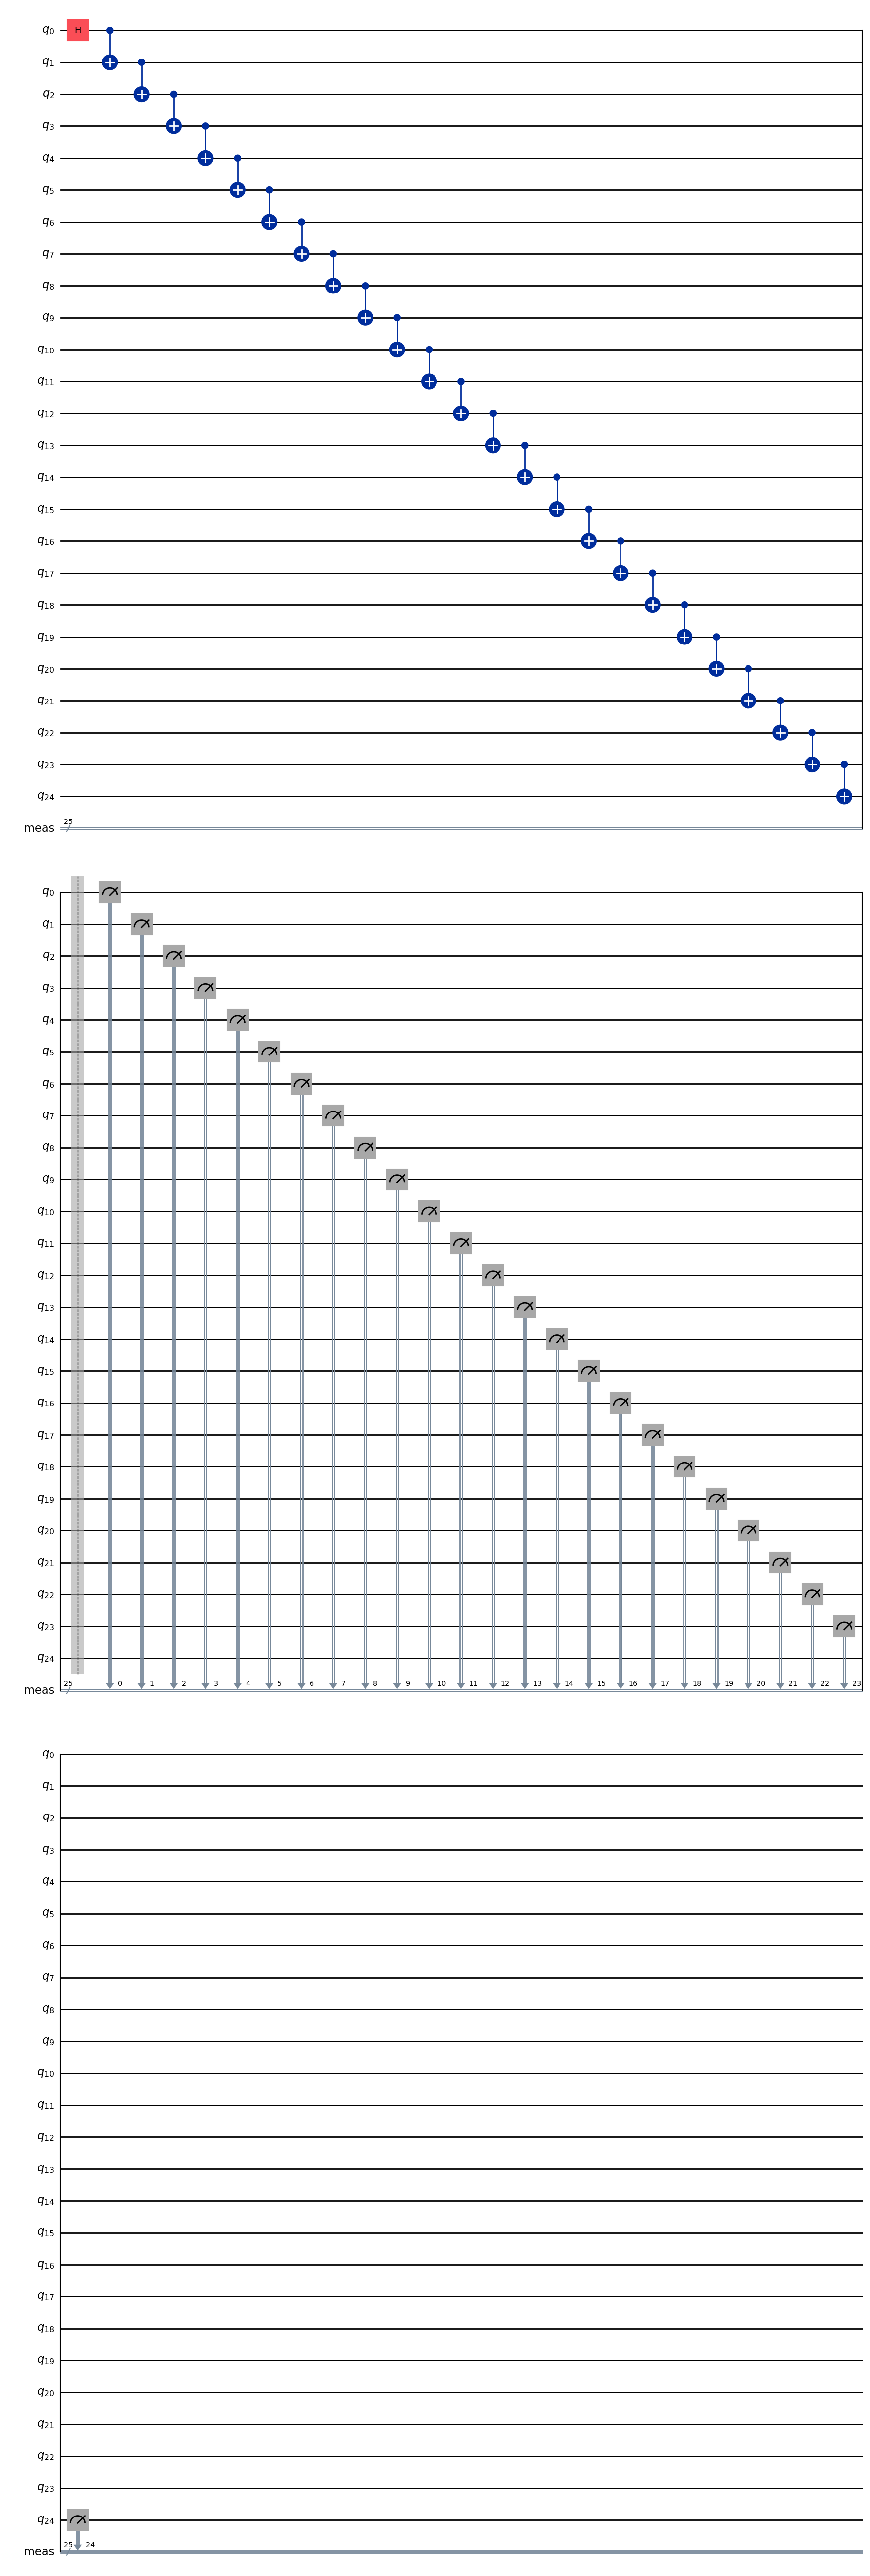

In [ ]:
# Set the number of qubits to 24
n = 25

# Create a quantum circuit with 'n' qubits
qc = QuantumCircuit(n)

# Apply a Hadamard gate to the last qubit (qubit n-1)
qc.h(0)

# Apply a series of CNOT (CX) gates in a chain, from the last qubit to the first
for i in range(n-1):
    qc.cx(i, i+1)

# Measure all qubits
qc.measure_all()
qc.draw('mpl')

In [ ]:
# Execute the quantum circuit 'qc' on the Basic simulator with 1024 shots
# using the 'statevector' method, and get the result
result = simulator_basic.run(qc, shots=1024, method='statevector').result()

# Get the counts of measurement outcomes from the result
counts = result.get_counts()

# Print the counts
print(counts)

<ipython-input-35-f256a5b7e1bf>:3: UserWarning: Option method is not used by this backend
  result = simulator_basic.run(qc, shots=1024, method='statevector').result()


BasicProviderError: 'Number of qubits 25 is greater than maximum (24) for "basic_simulator".'

In [ ]:
# Measure and display the time taken to execute the following code block
%%time

# Execute the quantum circuit 'qc' on the Aer simulator with 1024 shots
# using the 'matrix_product_state' method, and get the result
result = simulator_aer.run(qc, shots=1024, method='matrix_product_state').result()

# Get the counts of measurement outcomes from the result
counts = result.get_counts()

# Print the counts
print(counts)

{'0000000000000000000000000': 506, '1111111111111111111111111': 518}
CPU times: user 212 ms, sys: 2.78 ms, total: 215 ms
Wall time: 114 ms


## Noise in simulation

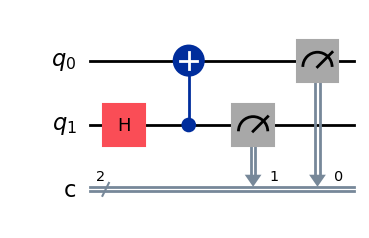

In [ ]:
# Create a quantum circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

# Apply a Hadamard gate to the second qubit (qubit 1)
qc.h(1)

# Apply a CNOT (CX) gate with the second qubit (qubit 1) as the control and the first qubit (qubit 0) as the target
qc.cx(1, 0)

# Measure both qubits and store the results in the corresponding classical bits
qc.measure([1, 0], [1, 0])

# Draw the quantum circuit using Matplotlib
qc.draw('mpl')

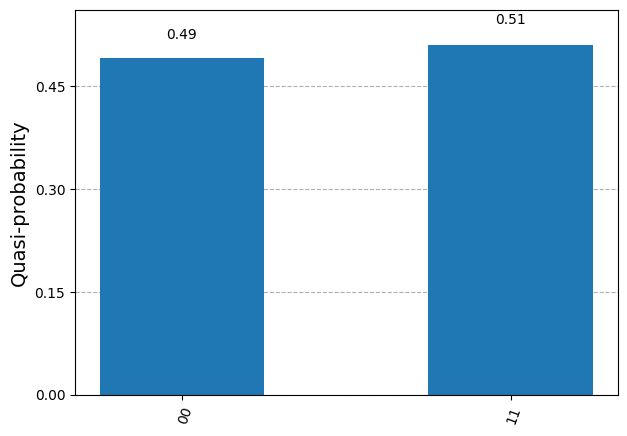

In [ ]:
# Transpile the quantum circuit 'qc' for the Aer simulator backend
qc_aer = transpile(qc, backend=simulator_aer)

# Execute the transpiled quantum circuit on the Aer simulator with 1024 shots and get the result
result_ideal = simulator_aer.run(qc_aer, shots=1024).result()

# Get the counts of measurement outcomes from the result
counts_ideal = result_ideal.get_counts()

# Plot the distribution of the measurement outcomes
plot_distribution(counts_ideal)

**Depolarizing Noise**

Depolarizing noise represents a quantum operation where, with probability (p), the state of the qubits is replaced by the maximally mixed state:

$
\rho \rightarrow (1 - p) \rho + \frac{p}{d} \mathbb{I}
$

where ($
\rho
$) is the density matrix of the qubit(s), (d) is the dimension of the Hilbert space (for (n) qubits, ($
d = 2^n
$)), and ($
\mathbb{I}
$) is the identity matrix.

In this simulation, the noise model applies a depolarizing error with probability (p = 0.1) to all 2-qubit CX gates, reflecting realistic noise behavior in quantum devices.


In [ ]:
# Import the noise module from qiskit_aer
from qiskit_aer import noise

# Set the probability of depolarizing error
prob = 0.1

# Create a depolarizing error with the specified probability for 2 qubits (used for CX gates)
error = noise.depolarizing_error(prob, 2)

# Initialize a noise model
noise_model = noise.NoiseModel()

# Add the depolarizing error to all CX (CNOT) gates in the noise model
noise_model.add_all_qubit_quantum_error(error, ['cx'])

# Get the basis gates supported by the noise model
basis_gates = noise_model.basis_gates

# Execute the quantum circuit 'qc' on the Aer simulator with 1024 shots,
# using the specified noise model and basis gates, and get the result
result_noisy = simulator_aer.run(qc,
                                 shots=1024,
                                 noise_model=noise_model,
                                 basis_gates=basis_gates).result()

# Get the counts of measurement outcomes from the noisy simulation result
counts_noisy = result_noisy.get_counts()

# Plot the distribution of counts from both the noiseless and noisy simulations
plot_distribution([counts_ideal, counts_noisy], title='Noiseless vs. Noisy simulated counts')

## Primitives V2 in Qiskit

### **Sampler**

In [ ]:
# Import StatevectorSampler and StatevectorEstimator from qiskit.primitives
from qiskit.primitives import StatevectorSampler, StatevectorEstimator

# Create a quantum circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

# Apply a Hadamard gate to the second qubit (qubit 1)
qc.h(1)

# Apply a CNOT (CX) gate with the second qubit (qubit 1) as the control and the first qubit (qubit 0) as the target
qc.cx(1, 0)

# Measure both qubits and store the results in the corresponding classical bits
qc.measure([1, 0], [1, 0])

# Display the quantum circuit using Matplotlib
display(qc.draw('mpl'))

# Initialize a StatevectorSampler, which works similarly to get_count and get_memory
sampler = StatevectorSampler()

# Execute the quantum circuit 'qc' on the basic simulator with 1024 shots
job_simulator = simulator_basic.run(qc, shots=1024)

# Since only basic gates (Hadamard and CNOT) are used, there is no need to transpile the circuit

In [ ]:
# Attempt to run the quantum circuit 'qc' using the StatevectorSampler with 1024 shots
# Note: This will result in an error because StatevectorSampler does not accept a quantum circuit directly
# It requires a Primitive Unified Block (PUB) as input instead
job_sampler = sampler.run(qc, shots=1024)

In [ ]:
# Run the StatevectorSampler on a list containing the quantum circuit 'qc' with 1024 shots
# Note: A Primitive Unified Block (PUB) consists of circuits, parameters, and the number of shots
job_sampler = sampler.run([qc], shots=1024)

In [ ]:
# Retrieve the result from the quantum circuit execution on the basic simulator
result_simulator = job_simulator.result()

# Retrieve the result from the StatevectorSampler job
result_sampler = job_sampler.result()

In [ ]:
# Get the counts of measurement outcomes from the simulator result
counts_simulator = result_simulator.get_counts()

# Print the measurement counts
print(counts_simulator)

In [ ]:
counts_sampler = result_sampler.get_counts()

In [ ]:
# Print the full result object obtained from the StatevectorSampler
print(result_sampler)

In [ ]:
# Print the first item in the result obtained from the StatevectorSampler
print(result_sampler[0])

In [ ]:
# Print the data attribute of the first item in the result obtained from the StatevectorSampler
print(result_sampler[0].data)

In [ ]:
# Print the 'c' attribute of the data from the first item in the result obtained from the StatevectorSampler
# The 'c' attribute relates to the names of classical bits
print(result_sampler[0].data.c)

refer to qiskit bitarray documentation https://docs.quantum.ibm.com/api/qiskit/qiskit.primitives.BitArray

In [ ]:
# Print the counts of measurement outcomes from the 'c' attribute of the data
# in the first item of the result obtained from the StatevectorSampler
print(result_sampler[0].data.c.get_counts())

In [ ]:
# Import the Parameter class from qiskit.circuit
from qiskit.circuit import Parameter

# Define a parameter 'theta'
theta = Parameter('theta')

# Create a quantum circuit with 2 qubits
qc2 = QuantumCircuit(2)

# Apply an RX rotation gate with parameter 'theta' to the second qubit (qubit 1)
qc2.rx(theta, 1)

# Apply a CNOT (CX) gate with the second qubit (qubit 1) as the control and the first qubit (qubit 0) as the target
qc2.cx(1, 0)

# Measure all qubits
qc2.measure_all()

# Draw the quantum circuit using Matplotlib
qc2.draw('mpl')

In [ ]:
# Import the math module for mathematical functions
import math

# Define a list of angles to be used for the parameter 'theta'
angles = [[math.pi/4], [math.pi/3], [math.pi/2]]

# Initialize an empty list to store the quantum circuits
circuits = []

# Loop through the list of angles
for angle in angles:
    # Create a temporary quantum circuit by assigning the parameter 'theta' to the current angle
    qc_temp = qc2.assign_parameters({theta: angle[0]})

    # Append the temporary circuit to the list of circuits
    circuits.append(qc_temp)

# Loop through the list of circuits and display each one using Matplotlib
for i in range(len(angles)):
    display(circuits[i].draw('mpl'))

In [ ]:
# Transpile the list of circuits for the basic simulator backend
circuits_t = transpile(circuits, backend=simulator_basic)

# Execute the transpiled circuits on the basic simulator with 1024 shots and get the result
result_simulator = simulator_basic.run(circuits_t, shots=1024).result()

In [ ]:
# Initialize an empty list to store the counts from the simulator
counts_simulator = []

# Loop through the list of angles, retrieving the counts for each corresponding circuit
for i, _ in enumerate(angles):
    # Get the counts for the i-th circuit result
    result_temp = result_simulator.get_counts(i)

    # Append the counts to the counts_simulator list
    counts_simulator.append(result_temp)

# Print the list of counts from the simulator
print(counts_simulator)

In [ ]:
# Run the StatevectorSampler with a Primitive Unified Block (PUB) consisting of the quantum circuit 'qc2'
# and the list of angles as parameters, with 1024 shots. Retrieve the result.
result_sampler = sampler.run([(qc2, angles)], shots=1024).result()

In [ ]:
# Initialize an empty list to store the counts from the sampler
counts_sampler = []

# Loop through the list of angles, retrieving the counts for each corresponding circuit
for i in range(len(angles)):
    # Get the counts for the i-th result from the sampler
    result_temp = result_sampler[0].data.meas.get_counts(i)

    # Append the counts to the counts_sampler list
    counts_sampler.append(result_temp)

# Print the list of counts from the sampler
print(counts_sampler)

In [ ]:
# Print the total counts from all different circuits combined in the sampler result
print(result_sampler[0].data.meas.get_counts())

# Print the result of each circuit separately from the simulator result
print(result_simulator.get_counts())

In [ ]:
# Create a quantum circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

# Apply a Hadamard gate to the second qubit (qubit 1)
qc.h(1)

# Apply a CNOT (CX) gate with the second qubit (qubit 1) as the control and the first qubit (qubit 0) as the target
qc.cx(1, 0)

# Measure both qubits and store the results in the corresponding classical bits
qc.measure([1, 0], [1, 0])

# Draw the quantum circuit using Matplotlib
qc.draw('mpl')

In [ ]:
# Run the StatevectorSampler with two Primitive Unified Blocks (PUBs):
# 1. The quantum circuit 'qc2' with the list of 'angles' as parameters.
# 2. The quantum circuit 'qc' with no parameters (None).
# Perform 1024 shots and retrieve the result.
result_sampler = sampler.run([(qc2, angles), (qc, None)], shots=1024).result()

In [ ]:
# Loop through the list of angles and print the counts for each corresponding circuit in the first PUB result
for i in range(len(angles)):
    print(f"First PUB's result with {i}th angle of the list: {result_sampler[0].data.meas.get_counts(i)}")

# Print the counts for the second PUB result (corresponding to the 'qc' circuit)
print(f"Second PUB's result: {result_sampler[1].data.c.get_counts()}")

In [ ]:
# Retrieve the measurement counts from the first PUB result in 'result_sampler'
# If the input to get_counts() is not specified, it sums up all measurement outputs
result_sampler[0].data.meas.get_counts()

In [ ]:
# Run the StatevectorSampler with two Primitive Unified Blocks (PUBs):
# 1. The quantum circuit 'qc2' with the list of 'angles' as parameters, and 1024 shots.
# 2. The quantum circuit 'qc' with no parameters (None), and 100 shots.
# Each PUB can specify its own number of shots.
result_sampler = sampler.run([(qc2, angles, 1024), (qc, None, 100)]).result()

In [ ]:
# Loop through the list of angles and print the measurement counts for each corresponding circuit
# from the first PUB result in 'result_sampler'
for i in range(len(angles)):
    print(f"First PUB's result with {i}th angle of the list and specified number of shots:{result_sampler[0].data.meas.get_counts(i)}")

# Print the measurement counts for the second PUB result in 'result_sampler'
# This result corresponds to the quantum circuit 'qc' with 100 shots
print(f"Second PUB's result with specified number of shots:{result_sampler[1].data.c.get_counts()}")

In [ ]:
result_sampler[0].data.meas.get_counts()

Sampler uses quantum_info package so avoid using it with midcircuit measures

In [ ]:
# Create a quantum circuit with 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1)

# Apply a Hadamard gate to the single qubit (qubit 0)
qc.h(0)

# Measure the qubit (qubit 0) and store the result in the classical bit (bit 0)
qc.measure(0, 0)

# Apply a conditional X (NOT) gate to the qubit (qubit 0)
# The gate is applied if the classical bit (bit 0) is equal to 1
qc.x(0).c_if(0, 1)

# Measure the qubit (qubit 0) again and store the result in the classical bit (bit 0)
qc.measure(0, 0)

# Draw the quantum circuit using Matplotlib
qc.draw('mpl')

In [ ]:
result_sampler = sampler.run([qc], shots=1024).result()

### **Estimator**

It doesn't accept measurements

In [ ]:
# Import the Parameter class from qiskit.circuit
from qiskit.circuit import Parameter

# Define a parameter 'theta' that can be adjusted later
theta = Parameter('θ')

# Create a quantum circuit with 2 qubits
qc2 = QuantumCircuit(2)

# Apply an RX rotation gate with the parameter 'theta' to the second qubit (qubit 1)
qc2.rx(theta, 1)

# Apply a CNOT (CX) gate with the second qubit (qubit 1) as the control and the first qubit (qubit 0) as the target
qc2.cx(1, 0)

# Draw the quantum circuit using Matplotlib
qc2.draw('mpl')

The observables we defined are quantum operators, typically used in quantum mechanics to represent measurements on quantum states. In quantum computing, these observables are often used to measure specific properties of qubits, such as correlations between qubits in different states.

Here’s a breakdown of what each observable represents:

1. **SparsePauliOp(["XX", "IY"], [0.5, 0.5])**:
   - This represents a linear combination of two Pauli operators: "XX" and "IY".
   - "XX" is the tensor product of two Pauli-X operators, acting on two qubits. Pauli-X is the quantum NOT gate, which flips a qubit's state.
   - "IY" represents a tensor product of an Identity operator (I) on the first qubit and a Pauli-Y operator on the second qubit. Pauli-Y is a bit and phase flip.
   - The coefficients `[0.5, 0.5]` indicate that this observable is a weighted combination of these two operators, with each contributing equally.

   Mathematically, this observable can be written as:
   \[
   0.5 . XX + 0.5 . IY
   \]

2. **SparsePauliOp(["XX"], [1])**:
   - This represents the operator "XX", which is the tensor product of two Pauli-X operators.
   - The coefficient `[1]` means that this operator is not weighted and is used as is.

   Mathematically, this observable is:
   \[
   XX
   \]

**Usage in Quantum Computing**:
- **Observables**: In quantum algorithms like the Variational Quantum Eigensolver (VQE) or Quantum Phase Estimation (QPE), these observables can be used to measure properties such as energy or correlations in a quantum state.
  
- **Measurements**: When a quantum state is measured against an observable like this, the result gives you information about the expected value (or eigenvalue) of the state with respect to that operator.

In [ ]:
# Import the SparsePauliOp class from qiskit.quantum_info
from qiskit.quantum_info import SparsePauliOp

# Define two observables using SparsePauliOp
# The first observable consists of two Pauli operators: "XX" and "IY", each with a coefficient of 0.5
# The second observable consists of a single Pauli operator: "XX" with a coefficient of 1
obsv = [
    [SparsePauliOp(["XX", "IY"], [0.5, 0.5])],  # First observable
    [SparsePauliOp(["XX"], [1])]                # Second observable
]

In [ ]:
# Initialize a StatevectorEstimator object, which is used to estimate the expectation values of observables
# for quantum states represented by quantum circuits (statevectors).
estimator = StatevectorEstimator()

# Run the estimator on a list of Primitive Unified Blocks (PUBs).
# The PUB in this case is (qc2, obsv, angles, 0.1), where:
# - qc2: the quantum circuit being evaluated
# - obsv: the observable(s) to measure (a list of SparsePauliOps)
# - angles: the parameter(s) used in the circuit (for parameterized circuits)
# - 0.1: a constant scaling factor or weight for the expectation value calculation
result_estimator = estimator.run([(qc2, obsv, angles, 0.1)]).result()

# Access the estimated expectation values (evs) from the result of the first element in the result set.
# The `evs` attribute contains the computed expectation values of the observables with respect to the circuit state.
result_estimator[0].data.evs